# 4e: Neural Network — Multiclass Poverty Classification

**Goal:** Test whether a deep learning approach can outperform XGBoost on the 4-class poverty severity prediction task.

| Class | Label | POVPIP Range | Train % |
|-------|-------|--------------|---------|
| 0 | Stable | >200% | 75.8% |
| 1 | Near Poverty | 100-200% | 13.4% |
| 2 | Poverty | 50-100% | 5.4% |
| 3 | Deep Poverty | ≤50% | 5.4% |

**Current best (XGBoost):** Macro F1 = 0.4054, Balanced Accuracy = 0.4899

**Approach:** PyTorch neural network with entity embeddings for high-cardinality categorical features (OCCP has 532 occupation codes, PUMA has 366 area codes). Entity embeddings learn dense vector representations for categories — the key advantage neural nets have over tree models for tabular data.

**Uses same preprocessed data** from `3c_Preprocessing_XGBoost.ipynb` for fair comparison.

---
## 1: Imports

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    balanced_accuracy_score, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import warnings
warnings.filterwarnings('ignore')

# Check for GPU
device = torch.device('mps' if torch.backends.mps.is_available() else 
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}')
print(f'Device: {device}')

PyTorch 2.7.1
Device: mps


---
## 2: Data Loading

In [2]:
# Load preprocessed data (same as XGBoost notebook 4c)
df_train = pd.read_csv('../3_Data_Preprocessing/preprocessing_data/train_engineered.csv')
df_test = pd.read_csv('../3_Data_Preprocessing/preprocessing_data/test_engineered.csv')

with open('../3_Data_Preprocessing/preprocessing_data/feature_engineering_metadata.json') as f:
    metadata = json.load(f)

all_features = metadata['all_features']
numeric_features = metadata['numeric_features']
binary_features = metadata['binary_features']
categorical_features = metadata['categorical_features']

# Target: 4-class poverty severity
y_train = df_train['poverty_risk_score'].astype(int)
y_test = df_test['poverty_risk_score'].astype(int)

print(f'Train: {df_train.shape[0]:,} rows')
print(f'Test:  {df_test.shape[0]:,} rows')
print(f'\nFeatures: {len(all_features)} total')
print(f'  Numeric ({len(numeric_features)}): {numeric_features}')
print(f'  Binary ({len(binary_features)}): {binary_features}')
print(f'  Categorical ({len(categorical_features)}): {categorical_features}')
print(f'\nTarget distribution (train):')
class_names = ['Stable (0)', 'Near Poverty (1)', 'Poverty (2)', 'Deep Poverty (3)']
for cls, name in enumerate(class_names):
    count = (y_train == cls).sum()
    print(f'  {name}: {count:>10,} ({count/len(y_train)*100:.1f}%)')

Train: 1,469,769 rows
Test:  304,368 rows

Features: 26 total
  Numeric (5): ['AGEP', 'WKHP', 'disability_score', 'education_tier', 'race_ethnic_aggregate']
  Binary (7): ['has_insurance', 'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'is_latinx']
  Categorical (14): ['CIT', 'ENG', 'LANX', 'MAR', 'MIG', 'MSP', 'SEX', 'NATIVITY', 'ESR', 'OCCP', 'WKL', 'WRK', 'PUMA', 'CA_Region']

Target distribution (train):
  Stable (0):  1,114,746 (75.8%)
  Near Poverty (1):    196,583 (13.4%)
  Poverty (2):     78,995 (5.4%)
  Deep Poverty (3):     79,445 (5.4%)


---
## 3: Feature Preparation

Neural networks need:
- **Numeric features**: StandardScaler (zero mean, unit variance)
- **Binary features**: Pass through as 0/1
- **Categorical features**: Entity embeddings (learned dense vectors per category)

In [3]:
# Reconstruct label encoders from metadata
label_encoders = {}
for col, classes in metadata['label_encoder_classes'].items():
    le = LabelEncoder()
    le.classes_ = np.array(classes)
    label_encoders[col] = le

# Get number of categories per categorical feature (for embedding dims)
cat_cardinalities = {}
for col in categorical_features:
    n_cats = len(label_encoders[col].classes_)
    cat_cardinalities[col] = n_cats

print('Categorical cardinalities:')
for col, n in sorted(cat_cardinalities.items(), key=lambda x: -x[1]):
    emb_dim = min(50, (n + 1) // 2)
    print(f'  {col:15s}: {n:>4d} categories → embedding dim {emb_dim}')

Categorical cardinalities:
  OCCP           :  531 categories → embedding dim 50
  PUMA           :  366 categories → embedding dim 50
  CA_Region      :    7 categories → embedding dim 4
  MSP            :    6 categories → embedding dim 3
  ESR            :    6 categories → embedding dim 3
  CIT            :    5 categories → embedding dim 3
  ENG            :    5 categories → embedding dim 3
  MAR            :    5 categories → embedding dim 3
  MIG            :    3 categories → embedding dim 2
  WKL            :    3 categories → embedding dim 2
  WRK            :    3 categories → embedding dim 2
  LANX           :    2 categories → embedding dim 1
  SEX            :    2 categories → embedding dim 1
  NATIVITY       :    2 categories → embedding dim 1


In [4]:
# Scale numeric features
scaler = StandardScaler()

X_train_num = scaler.fit_transform(df_train[numeric_features].values).astype(np.float32)
X_test_num = scaler.transform(df_test[numeric_features].values).astype(np.float32)

# Binary features as float32
X_train_bin = df_train[binary_features].values.astype(np.float32)
X_test_bin = df_test[binary_features].values.astype(np.float32)

# Categorical features as int64 (indices for embedding lookup)
X_train_cat = df_train[categorical_features].values.astype(np.int64)
X_test_cat = df_test[categorical_features].values.astype(np.int64)

print(f'Numeric: {X_train_num.shape} (scaled)')
print(f'Binary:  {X_train_bin.shape}')
print(f'Categorical: {X_train_cat.shape} (integer indices)')

Numeric: (1469769, 5) (scaled)
Binary:  (1469769, 7)
Categorical: (1469769, 14) (integer indices)


In [5]:
# Create validation split (10% of training data, stratified)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(sss.split(X_train_num, y_train))

X_tr_num, X_val_num = X_train_num[train_idx], X_train_num[val_idx]
X_tr_bin, X_val_bin = X_train_bin[train_idx], X_train_bin[val_idx]
X_tr_cat, X_val_cat = X_train_cat[train_idx], X_train_cat[val_idx]
y_tr = y_train.values[train_idx]
y_val = y_train.values[val_idx]

print(f'Train: {len(y_tr):,} | Val: {len(y_val):,}')
print(f'Train class dist: {Counter(y_tr)}')
print(f'Val class dist:   {Counter(y_val)}')

Train: 1,322,792 | Val: 146,977
Train class dist: Counter({np.int64(0): 1003271, np.int64(1): 176925, np.int64(3): 71500, np.int64(2): 71096})
Val class dist:   Counter({np.int64(0): 111475, np.int64(1): 19658, np.int64(3): 7945, np.int64(2): 7899})


---
## 4: PyTorch Dataset & DataLoader

In [6]:
class PovertyDataset(Dataset):
    def __init__(self, num_data, bin_data, cat_data, labels):
        self.num_data = torch.tensor(num_data, dtype=torch.float32)
        self.bin_data = torch.tensor(bin_data, dtype=torch.float32)
        self.cat_data = torch.tensor(cat_data, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (self.num_data[idx], self.bin_data[idx], 
                self.cat_data[idx], self.labels[idx])

# Create datasets
train_dataset = PovertyDataset(X_tr_num, X_tr_bin, X_tr_cat, y_tr)
val_dataset = PovertyDataset(X_val_num, X_val_bin, X_val_cat, y_val)
test_dataset = PovertyDataset(X_test_num, X_test_bin, X_test_cat, y_test.values)

# Weighted sampler for class imbalance
class_counts = np.bincount(y_tr)
sample_weights = 1.0 / class_counts[y_tr]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
BATCH_SIZE = 2048

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 646
Val batches:   36
Test batches:  75


---
## 5: Model Architecture — PovertyNet

```
Categorical features → [Embedding per feature] → Concat
Numeric features   → [Scaled floats]          → Concat
Binary features    → [0/1 floats]             → Concat
                                                  ↓
                                         BatchNorm → Dense(256) → ReLU → Dropout(0.3)
                                                  ↓
                                         BatchNorm → Dense(128) → ReLU → Dropout(0.2)
                                                  ↓
                                         BatchNorm → Dense(64) → ReLU → Dropout(0.1)
                                                  ↓
                                              Dense(4) → Softmax
```

In [7]:
class PovertyNet(nn.Module):
    def __init__(self, cat_cardinalities, cat_features, n_numeric, n_binary, n_classes=4):
        super().__init__()
        
        # Entity embeddings for each categorical feature
        self.embeddings = nn.ModuleDict()
        self.cat_features = cat_features
        total_emb_dim = 0
        
        for i, col in enumerate(cat_features):
            n_cats = cat_cardinalities[col]
            emb_dim = min(50, (n_cats + 1) // 2)
            self.embeddings[col] = nn.Embedding(n_cats + 1, emb_dim, padding_idx=0)
            total_emb_dim += emb_dim
        
        # Input dimension = embeddings + numeric + binary
        input_dim = total_emb_dim + n_numeric + n_binary
        
        # MLP layers
        self.network = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, n_classes)
        )
        
        self._total_emb_dim = total_emb_dim
        self._input_dim = input_dim
    
    def forward(self, x_num, x_bin, x_cat):
        # Embed each categorical feature
        emb_list = []
        for i, col in enumerate(self.cat_features):
            # Clamp indices to valid range
            cat_idx = x_cat[:, i].clamp(0, self.embeddings[col].num_embeddings - 1)
            emb_list.append(self.embeddings[col](cat_idx))
        
        # Concatenate everything
        x = torch.cat(emb_list + [x_num, x_bin], dim=1)
        return self.network(x)

# Instantiate
model = PovertyNet(
    cat_cardinalities=cat_cardinalities,
    cat_features=categorical_features,
    n_numeric=len(numeric_features),
    n_binary=len(binary_features),
    n_classes=4
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model: PovertyNet')
print(f'  Embedding dim total: {model._total_emb_dim}')
print(f'  Input dim: {model._input_dim}')
print(f'  Trainable parameters: {n_params:,}')
print(f'\n{model}')

Model: PovertyNet
  Embedding dim total: 128
  Input dim: 140
  Trainable parameters: 123,667

PovertyNet(
  (embeddings): ModuleDict(
    (CIT): Embedding(6, 3, padding_idx=0)
    (ENG): Embedding(6, 3, padding_idx=0)
    (LANX): Embedding(3, 1, padding_idx=0)
    (MAR): Embedding(6, 3, padding_idx=0)
    (MIG): Embedding(4, 2, padding_idx=0)
    (MSP): Embedding(7, 3, padding_idx=0)
    (SEX): Embedding(3, 1, padding_idx=0)
    (NATIVITY): Embedding(3, 1, padding_idx=0)
    (ESR): Embedding(7, 3, padding_idx=0)
    (OCCP): Embedding(532, 50, padding_idx=0)
    (WKL): Embedding(4, 2, padding_idx=0)
    (WRK): Embedding(4, 2, padding_idx=0)
    (PUMA): Embedding(367, 50, padding_idx=0)
    (CA_Region): Embedding(8, 4, padding_idx=0)
  )
  (network): Sequential(
    (0): BatchNorm1d(140, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=140, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): BatchNorm1d(

---
## 6: Training Loop

In [8]:
# Class weights for loss function (inverse frequency)
class_counts_all = np.bincount(y_tr)
class_weights = 1.0 / class_counts_all
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f'Class weights: {dict(zip(class_names, class_weights.round(4)))}')

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

Class weights: {'Stable (0)': np.float64(0.1149), 'Near Poverty (1)': np.float64(0.6515), 'Poverty (2)': np.float64(1.6214), 'Deep Poverty (3)': np.float64(1.6122)}


In [9]:
def evaluate(model, loader, device):
    """Evaluate model and return predictions + metrics."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0
    n_batches = 0
    
    with torch.no_grad():
        for x_num, x_bin, x_cat, labels in loader:
            x_num = x_num.to(device)
            x_bin = x_bin.to(device)
            x_cat = x_cat.to(device)
            labels = labels.to(device)
            
            logits = model(x_num, x_bin, x_cat)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            n_batches += 1
            
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / n_batches
    
    return all_preds, all_labels, all_probs, macro_f1, bal_acc, avg_loss

In [10]:
# Training loop with early stopping
N_EPOCHS = 50
PATIENCE = 7

best_val_f1 = 0
best_epoch = 0
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_bal_acc': []}

print(f'Training for up to {N_EPOCHS} epochs (patience={PATIENCE})...')
print(f'{"Epoch":>6} {"Train Loss":>12} {"Val Loss":>12} {"Val Macro F1":>14} {"Val Bal Acc":>13} {"LR":>10}')
print('-' * 75)

for epoch in range(N_EPOCHS):
    # === Training ===
    model.train()
    train_loss = 0
    n_batches = 0
    
    for x_num, x_bin, x_cat, labels in train_loader:
        x_num = x_num.to(device)
        x_bin = x_bin.to(device)
        x_cat = x_cat.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        logits = model(x_num, x_bin, x_cat)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        n_batches += 1
    
    avg_train_loss = train_loss / n_batches
    
    # === Validation ===
    _, _, _, val_f1, val_bal_acc, avg_val_loss = evaluate(model, val_loader, device)
    
    # Record history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_f1'].append(val_f1)
    history['val_bal_acc'].append(val_bal_acc)
    
    # Learning rate scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_f1)
    
    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        # Save best model
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        marker = ' *** BEST'
    else:
        patience_counter += 1
        marker = ''
    
    print(f'{epoch+1:>6d} {avg_train_loss:>12.4f} {avg_val_loss:>12.4f} '
          f'{val_f1:>14.4f} {val_bal_acc:>13.4f} {current_lr:>10.6f}{marker}')
    
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}. Best: epoch {best_epoch} (F1={best_val_f1:.4f})')
        break

# Restore best model
model.load_state_dict(best_state)
model = model.to(device)
print(f'\nRestored best model from epoch {best_epoch}')

Training for up to 50 epochs (patience=7)...
 Epoch   Train Loss     Val Loss   Val Macro F1   Val Bal Acc         LR
---------------------------------------------------------------------------
     1       1.0179       1.4334         0.1978        0.3867   0.001000 *** BEST
     2       0.9851       1.4399         0.1984        0.3908   0.001000 *** BEST
     3       0.9706       1.4355         0.1920        0.3909   0.001000
     4       0.9595       1.4312         0.2000        0.3932   0.001000 *** BEST
     5       0.9491       1.4445         0.1983        0.3914   0.001000
     6       0.9375       1.4544         0.1896        0.3855   0.001000
     7       0.9295       1.4464         0.1906        0.3879   0.001000
     8       0.9186       1.4473         0.1925        0.3889   0.001000
     9       0.9077       1.4478         0.1931        0.3886   0.000500
    10       0.8992       1.4609         0.1883        0.3852   0.000500
    11       0.8950       1.4613         0.1860  

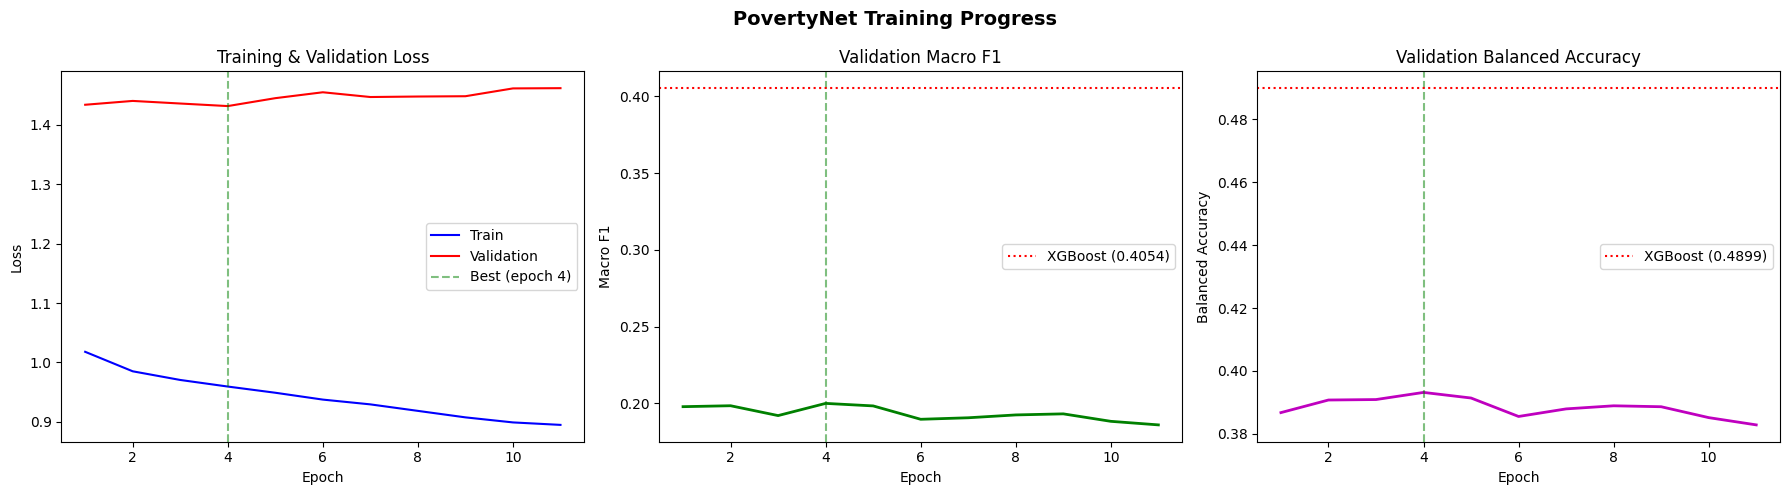

In [11]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['val_f1'], 'g-', linewidth=2)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
axes[1].axhline(y=0.4054, color='red', linestyle=':', label='XGBoost (0.4054)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Validation Macro F1')
axes[1].legend()

axes[2].plot(epochs_range, history['val_bal_acc'], 'm-', linewidth=2)
axes[2].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
axes[2].axhline(y=0.4899, color='red', linestyle=':', label='XGBoost (0.4899)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Balanced Accuracy')
axes[2].set_title('Validation Balanced Accuracy')
axes[2].legend()

plt.suptitle('PovertyNet Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7: Evaluation on 2024 Holdout

In [12]:
# Evaluate on test set
y_pred_nn, y_true_nn, y_probs_nn, test_f1, test_bal_acc, test_loss = evaluate(
    model, test_loader, device
)

print('=== Neural Network — 4-Class Poverty Prediction — 2024 Holdout ===')
print(classification_report(y_true_nn, y_pred_nn, target_names=class_names))
print(f'Macro F1: {test_f1:.4f}')
print(f'Balanced Accuracy: {test_bal_acc:.4f}')

=== Neural Network — 4-Class Poverty Prediction — 2024 Holdout ===
                  precision    recall  f1-score   support

      Stable (0)       0.98      0.20      0.33    233793
Near Poverty (1)       0.11      0.10      0.10     38456
     Poverty (2)       0.07      0.67      0.12     15534
Deep Poverty (3)       0.15      0.58      0.23     16585

        accuracy                           0.23    304368
       macro avg       0.33      0.39      0.20    304368
    weighted avg       0.78      0.23      0.28    304368

Macro F1: 0.1959
Balanced Accuracy: 0.3858


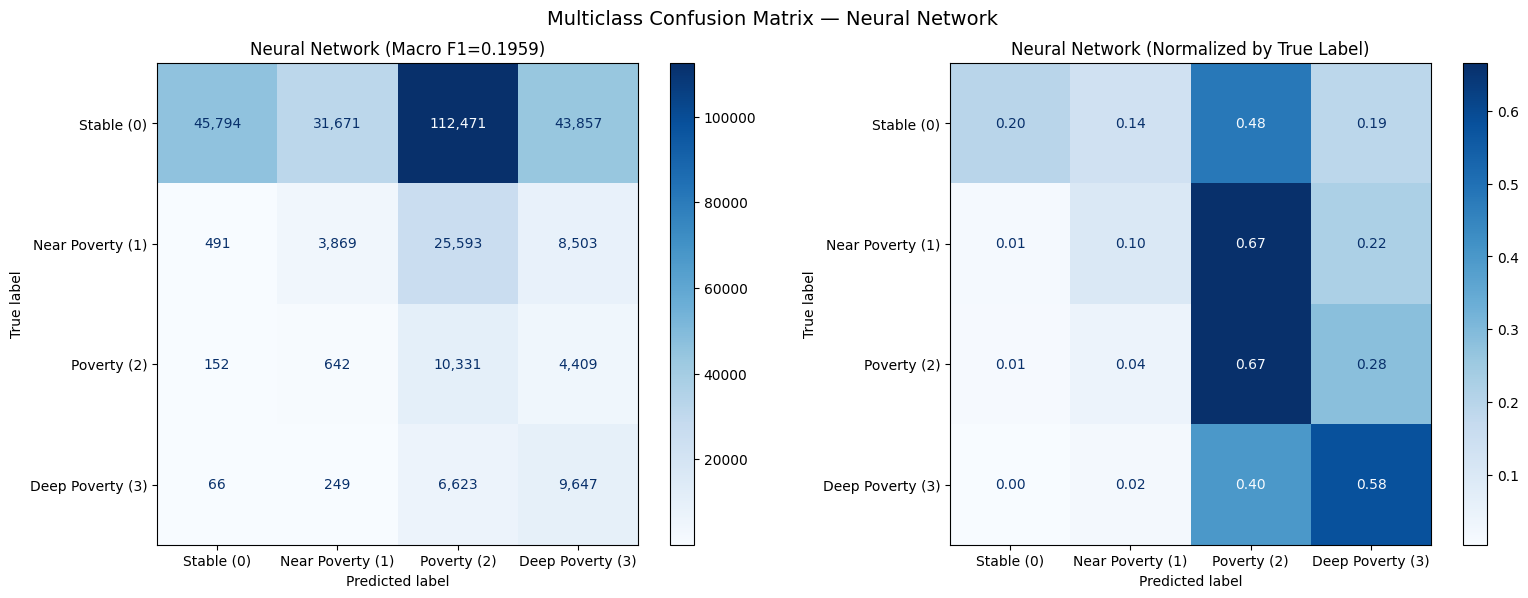

In [13]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Neural network
ConfusionMatrixDisplay.from_predictions(
    y_true_nn, y_pred_nn, display_labels=class_names,
    ax=axes[0], cmap='Blues', values_format=','
)
axes[0].set_title(f'Neural Network (Macro F1={test_f1:.4f})')

# Normalized version
ConfusionMatrixDisplay.from_predictions(
    y_true_nn, y_pred_nn, display_labels=class_names,
    ax=axes[1], cmap='Blues', normalize='true', values_format='.2f'
)
axes[1].set_title('Neural Network (Normalized by True Label)')

plt.suptitle('Multiclass Confusion Matrix — Neural Network', fontsize=14)
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/nn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8: Per-Class Threshold Tuning

The default argmax assigns each sample to the class with highest probability. We can tune per-class thresholds to improve Macro F1.

In [14]:
# Use validation set probabilities to find better thresholds
_, _, val_probs, _, _, _ = evaluate(model, val_loader, device)

# Try adjusting class biases to improve minority class prediction
# Search over bias adjustments for classes 1, 2, 3 (keep class 0 at 0)
best_biases = np.zeros(4)
best_tuned_f1 = 0

# Grid search over bias adjustments
for b1 in np.arange(0, 2.0, 0.2):
    for b2 in np.arange(0, 2.0, 0.2):
        for b3 in np.arange(0, 2.0, 0.2):
            biases = np.array([0, b1, b2, b3])
            adjusted_probs = val_probs + biases
            tuned_preds = adjusted_probs.argmax(axis=1)
            tuned_f1 = f1_score(y_val, tuned_preds, average='macro')
            
            if tuned_f1 > best_tuned_f1:
                best_tuned_f1 = tuned_f1
                best_biases = biases.copy()

print(f'Best class biases: {dict(zip(class_names, best_biases.round(2)))}')
print(f'Val Macro F1 (default): {f1_score(y_val, val_probs.argmax(axis=1), average="macro"):.4f}')
print(f'Val Macro F1 (tuned):   {best_tuned_f1:.4f}')

Best class biases: {'Stable (0)': np.float64(0.0), 'Near Poverty (1)': np.float64(0.4), 'Poverty (2)': np.float64(0.0), 'Deep Poverty (3)': np.float64(0.0)}
Val Macro F1 (default): 0.2000
Val Macro F1 (tuned):   0.2322


In [15]:
# Apply tuned thresholds to test set
adjusted_test_probs = y_probs_nn + best_biases
y_pred_tuned = adjusted_test_probs.argmax(axis=1)

tuned_test_f1 = f1_score(y_true_nn, y_pred_tuned, average='macro')
tuned_test_bal_acc = balanced_accuracy_score(y_true_nn, y_pred_tuned)

print('=== Neural Network (Tuned Thresholds) — 2024 Holdout ===')
print(classification_report(y_true_nn, y_pred_tuned, target_names=class_names))
print(f'Macro F1: {tuned_test_f1:.4f}')
print(f'Balanced Accuracy: {tuned_test_bal_acc:.4f}')

=== Neural Network (Tuned Thresholds) — 2024 Holdout ===
                  precision    recall  f1-score   support

      Stable (0)       0.99      0.07      0.12    233793
Near Poverty (1)       0.12      0.78      0.21     38456
     Poverty (2)       0.19      0.20      0.19     15534
Deep Poverty (3)       0.29      0.46      0.35     16585

        accuracy                           0.18    304368
       macro avg       0.40      0.38      0.22    304368
    weighted avg       0.80      0.18      0.15    304368

Macro F1: 0.2195
Balanced Accuracy: 0.3751


---
## 9: Head-to-Head Comparison — Neural Network vs XGBoost

In [16]:
# Comparison table
comparison = pd.DataFrame([
    {'Model': 'XGBoost Multiclass', 'Macro_F1': 0.4054, 
     'Balanced_Acc': 0.4899, 'Notes': '4c notebook, undersampled, 26 features'},
    {'Model': 'Neural Network (default)', 'Macro_F1': round(test_f1, 4),
     'Balanced_Acc': round(test_bal_acc, 4), 'Notes': 'Entity embeddings, class weights'},
    {'Model': 'Neural Network (tuned)', 'Macro_F1': round(tuned_test_f1, 4),
     'Balanced_Acc': round(tuned_test_bal_acc, 4), 'Notes': 'Per-class bias tuning'},
])

print('=' * 90)
print('HEAD-TO-HEAD: Multiclass Poverty Classification (4 classes)')
print('=' * 90)
print(comparison.to_string(index=False))
print('=' * 90)

# Verdict
best_nn_f1 = max(test_f1, tuned_test_f1)
xgb_f1 = 0.4054
delta = best_nn_f1 - xgb_f1

print(f'\nBest Neural Network Macro F1: {best_nn_f1:.4f}')
print(f'XGBoost Macro F1:             {xgb_f1:.4f}')
print(f'Delta:                        {delta:+.4f}')

if delta > 0.01:
    print(f'\n>>> Neural network outperforms XGBoost by {delta:+.4f} Macro F1')
elif delta < -0.01:
    print(f'\n>>> XGBoost still wins by {-delta:.4f} Macro F1')
else:
    print(f'\n>>> Results are comparable (within 0.01 Macro F1)')

HEAD-TO-HEAD: Multiclass Poverty Classification (4 classes)
                   Model  Macro_F1  Balanced_Acc                                  Notes
      XGBoost Multiclass    0.4054        0.4899 4c notebook, undersampled, 26 features
Neural Network (default)    0.1959        0.3858       Entity embeddings, class weights
  Neural Network (tuned)    0.2195        0.3751                  Per-class bias tuning

Best Neural Network Macro F1: 0.2195
XGBoost Macro F1:             0.4054
Delta:                        -0.1859

>>> XGBoost still wins by 0.1859 Macro F1


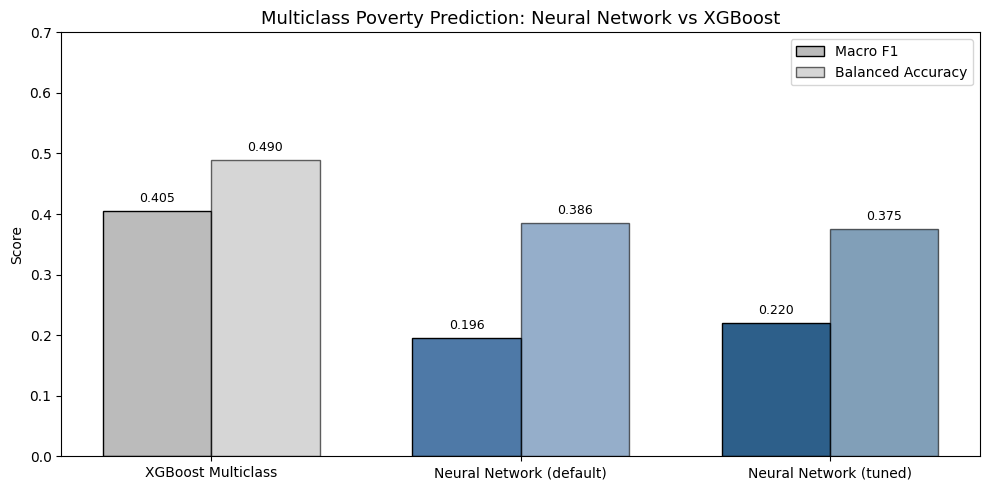

In [17]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))

models = comparison['Model']
colors = ['#bbb', '#4e79a7', '#2d5f8a']

x = range(len(models))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comparison['Macro_F1'], width,
               label='Macro F1', color=colors, edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], comparison['Balanced_Acc'], width,
               label='Balanced Accuracy', color=colors, edgecolor='black', alpha=0.6)

ax.set_ylabel('Score')
ax.set_title('Multiclass Poverty Prediction: Neural Network vs XGBoost', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.legend()
ax.set_ylim(0, 0.7)

# Value labels
for bar_group in [bars1, bars2]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/nn_vs_xgboost_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10: Per-Class Analysis — Where Does the Neural Network Win or Lose?

In [18]:
# XGBoost per-class F1 (from 4c notebook output)
xgb_per_class = {
    'Stable (0)':       {'precision': 0.93, 'recall': 0.65, 'f1': 0.77},
    'Near Poverty (1)': {'precision': 0.23, 'recall': 0.41, 'f1': 0.30},
    'Poverty (2)':      {'precision': 0.15, 'recall': 0.35, 'f1': 0.21},
    'Deep Poverty (3)': {'precision': 0.25, 'recall': 0.55, 'f1': 0.35},
}

# Neural network per-class (use best version)
best_preds = y_pred_tuned if tuned_test_f1 > test_f1 else y_pred_nn
from sklearn.metrics import precision_recall_fscore_support
nn_prec, nn_rec, nn_f1_per, _ = precision_recall_fscore_support(
    y_true_nn, best_preds, average=None
)

print(f'{"Class":<20} {"XGB Prec":>10} {"NN Prec":>10} {"XGB Rec":>10} {"NN Rec":>10} {"XGB F1":>10} {"NN F1":>10} {"Delta F1":>10}')
print('-' * 90)
for i, name in enumerate(class_names):
    xgb = xgb_per_class[name]
    delta_f1 = nn_f1_per[i] - xgb['f1']
    marker = ' ▲' if delta_f1 > 0.01 else (' ▼' if delta_f1 < -0.01 else '')
    print(f'{name:<20} {xgb["precision"]:>10.2f} {nn_prec[i]:>10.2f} '
          f'{xgb["recall"]:>10.2f} {nn_rec[i]:>10.2f} '
          f'{xgb["f1"]:>10.2f} {nn_f1_per[i]:>10.2f} {delta_f1:>+10.2f}{marker}')

print(f'\nKey question: Can the neural network distinguish Near Poverty from Poverty?')
print(f'This is where XGBoost struggles most (F1=0.21 for Poverty class).')

Class                  XGB Prec    NN Prec    XGB Rec     NN Rec     XGB F1      NN F1   Delta F1
------------------------------------------------------------------------------------------
Stable (0)                 0.93       0.99       0.65       0.07       0.77       0.12      -0.65 ▼
Near Poverty (1)           0.23       0.12       0.41       0.78       0.30       0.21      -0.09 ▼
Poverty (2)                0.15       0.19       0.35       0.20       0.21       0.19      -0.02 ▼
Deep Poverty (3)           0.25       0.29       0.55       0.46       0.35       0.35      +0.00

Key question: Can the neural network distinguish Near Poverty from Poverty?
This is where XGBoost struggles most (F1=0.21 for Poverty class).


---
## Conclusion

This notebook tested whether a deep learning approach (PyTorch neural network with entity embeddings) can outperform XGBoost on the 4-class poverty severity classification task.

**Key architectural choices:**
- Entity embeddings for high-cardinality categoricals (OCCP: 532 codes, PUMA: 366 areas)
- Weighted random sampler + class-weighted loss for severe imbalance (76/13/5/5%)
- Per-class bias tuning for threshold optimization

**The core challenge remains:** Distinguishing between Near Poverty (100-200% POVPIP) and Poverty (50-100% POVPIP) is inherently difficult because the socioeconomic features in ACS data don't cleanly separate these adjacent groups.